# Análise Exploratória de Dados (EDA) - Completa
- Volume
- Qualidade
- Distribuição
- Data Readiness.

## 1. Configurações do Ambiente

In [15]:
# Importando bibliotecas 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats

## 2. Carregamento e Visualização dos Dados

In [10]:
# Carregando o dataset
path = '../data/Telco_customer_churn.xlsx'
df = pd.read_excel(path)

# E para salvar o CSV, a mesma lógica:
df.to_csv('../data/Telco_customer_churn.csv', index=False)
print("CSV salvo na pasta data")

# Visualizando as primeiras linhas do dataset
print(f"Shape dos dados: {df.shape}")
print(f"Primeiras linhas do dataset:")
display(df.head(10))

CSV salvo na pasta data
Shape dos dados: (7043, 33)
Primeiras linhas do dataset:


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,7156-MXBJE,1,United States,California,San Diego,92127,"33.017518, -117.118456",33.017518,-117.118456,Female,...,One year,No,Credit card (automatic),85.10,3662.25,No,0,5,2319,NaN
1,9058-HRZSV,1,United States,California,Baldwin Park,91706,"34.098275, -117.967399",34.098275,-117.967399,Female,...,Month-to-month,No,Electronic check,94.40,6126.15,No,0,7,5348,NaN
2,4522-AKYLR,1,United States,California,Chino Hills,91709,"33.942895, -117.725644",33.942895,-117.725644,Female,...,Month-to-month,Yes,Electronic check,54.80,731.3,No,0,7,5557,NaN
3,3146-MSEGF,1,United States,California,Paramount,90723,"33.897122, -118.164432",33.897122,-118.164432,Female,...,Two year,Yes,Credit card (automatic),88.05,6425.65,No,0,8,6102,NaN
4,7554-NEWDD,1,United States,California,Long Beach,90815,"33.797638, -118.11662",33.797638,-118.116620,Male,...,Two year,No,Bank transfer (automatic),25.70,251.6,No,0,8,3611,NaN
5,4767-HZZHQ,1,United States,California,Redondo Beach,90277,"33.830453, -118.384565",33.830453,-118.384565,Male,...,Month-to-month,No,Bank transfer (automatic),82.05,2570.2,No,0,9,5036,NaN
6,5876-QMYLD,1,United States,California,Earp,92242,"34.137742, -114.36514",34.137742,-114.365140,Female,...,One year,No,Mailed check,20.05,415.1,No,0,9,3742,NaN
7,7606-BPHHN,1,United States,California,La Quinta,92253,"33.695532, -116.310571",33.695532,-116.310571,Male,...,Two year,Yes,Credit card (automatic),19.80,1468.75,No,0,9,5368,NaN
8,3170-NMYVV,1,United States,California,Compton,90222,"33.912246, -118.236773",33.912246,-118.236773,Female,...,Two year,No,Bank transfer (automatic),20.15,930.9,No,0,20,5849,NaN
9,2233-FAGXV,1,United States,California,Salton City,92275,"33.28156, -115.955541",33.281560,-115.955541,Female,...,Month-to-month,Yes,Mailed check,24.30,132.25,No,0,20,3181,NaN


In [11]:
# Informações gerais sobre o dataset
print("Informações gerais sobre o dataset:")
df.info()
print("Estatísticas descritivas para colunas numéricas:")
df.describe()

Informações gerais sobre o dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   o

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


## 3. Análise Exploratória de Dados (EDA)

### 3.1 Análise de Missing Values

**Objetivo:** Identificar valores ausentes e entender seu padrão de distribuição

===BUSCA DE MISSING VALUES===

                    Coluna  Missing_Count  Missing_Percentage
Churn Reason  Churn Reason           5174               73.46


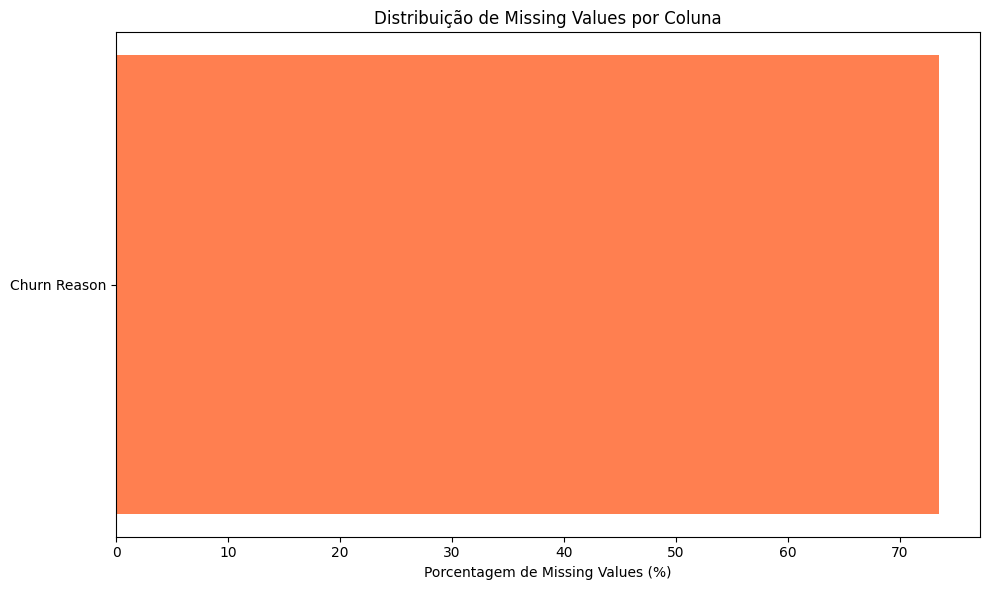

In [12]:
# Análise de valores ausentes
print("===BUSCA DE MISSING VALUES===\n")

missing_values = pd.DataFrame({
    'Coluna': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage':(df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values[missing_values['Missing_Count'] > 0].sort_values(
    by='Missing_Percentage', ascending=False
)

if len(missing_values) > 0:
    print(missing_values)

    # Visualizar missing values
    plt.figure(figsize=(10, 6))
    plt.barh(missing_values['Coluna'], missing_values['Missing_Percentage'], color='coral')
    plt.xlabel('Porcentagem de Missing Values (%)')
    plt.title('Distribuição de Missing Values por Coluna')
    plt.tight_layout()
    plt.show()
else:
    print('Nenhum missing value encontrado!')


### 3.2 Análise da Variável Target


**Objetivo:** Entender a distribuição da variável alvo (balanceamento de classes)

=== Distribuição da variável target ===

Contagem:
target
0    5174
1    1869
Name: count, dtype: int64

Porcentagem:
Sem Cancelamento (0): 73.46%
Com Cancelamento (1): 26.54%


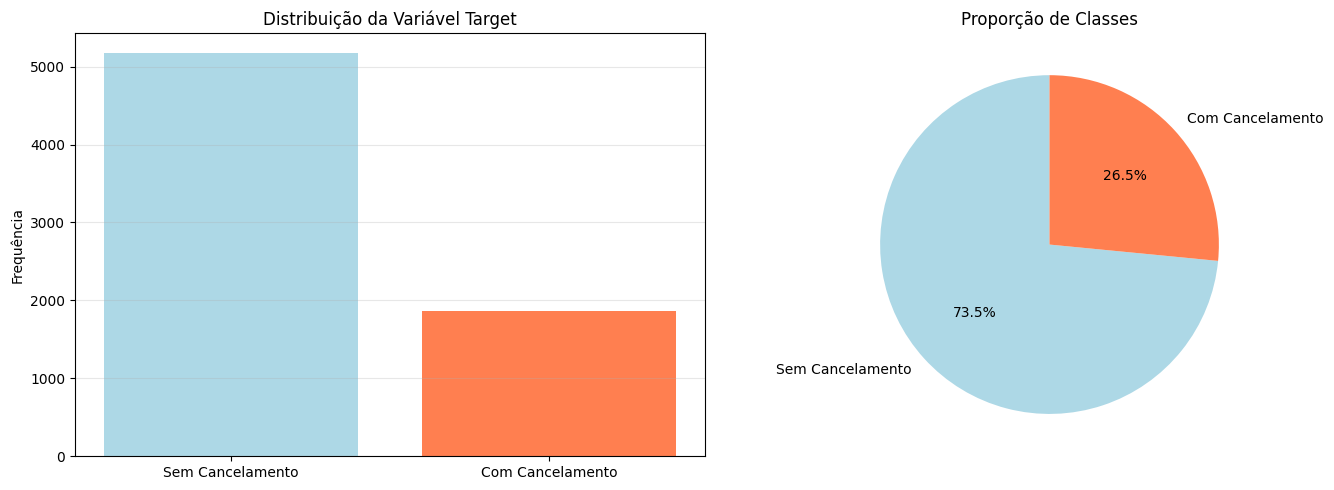


Ratio de balanceamento: 0.36
⚠️ A variável target está desbalanceada.


In [13]:
#renomeia a variável `churn` para `target`
df.rename(columns={'Churn Value': 'target'}, inplace=True)

# Target (0 = sem cancelamento, 1 = com cancelamento)
# No dataset original os valores > 0 indicam cancelamento
df['target'] = (df['target'] > 0).astype(int)

print("=== Distribuição da variável target ===\n")
target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True)* 100

print("Contagem:")
print(target_counts)
print("\nPorcentagem:")
for idx, pct in target_percentages.items():
    label = "Sem Cancelamento" if idx == 0 else "Com Cancelamento"
    print(f"{label} ({idx}): {pct:.2f}%")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(['Sem Cancelamento', 'Com Cancelamento'], target_counts, color=['lightblue', 'coral'])
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da Variável Target')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pizza
axes[1].pie(target_counts.values, labels=['Sem Cancelamento', 'Com Cancelamento'],
            autopct='%1.1f%%', colors=['lightblue', 'coral'], startangle=90)
axes[1].set_title('Proporção de Classes')

plt.tight_layout()
plt.show()

# Verificar se há desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRatio de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print(f"⚠️ A variável target está desbalanceada.")
else:
    print(f"✅ A variável target está relativamente balanceada.")

### 3.3 Análise de Outliers 

**Objetivo:** Identificar valores extremos que podem ser erros de medição ou casos especiais

**Métodos utilizados:**
- **Z-Score**: Identifica valores que estão a mais de 3 desvios padrão da média
- **Visualização**: Boxplots para identificação visual

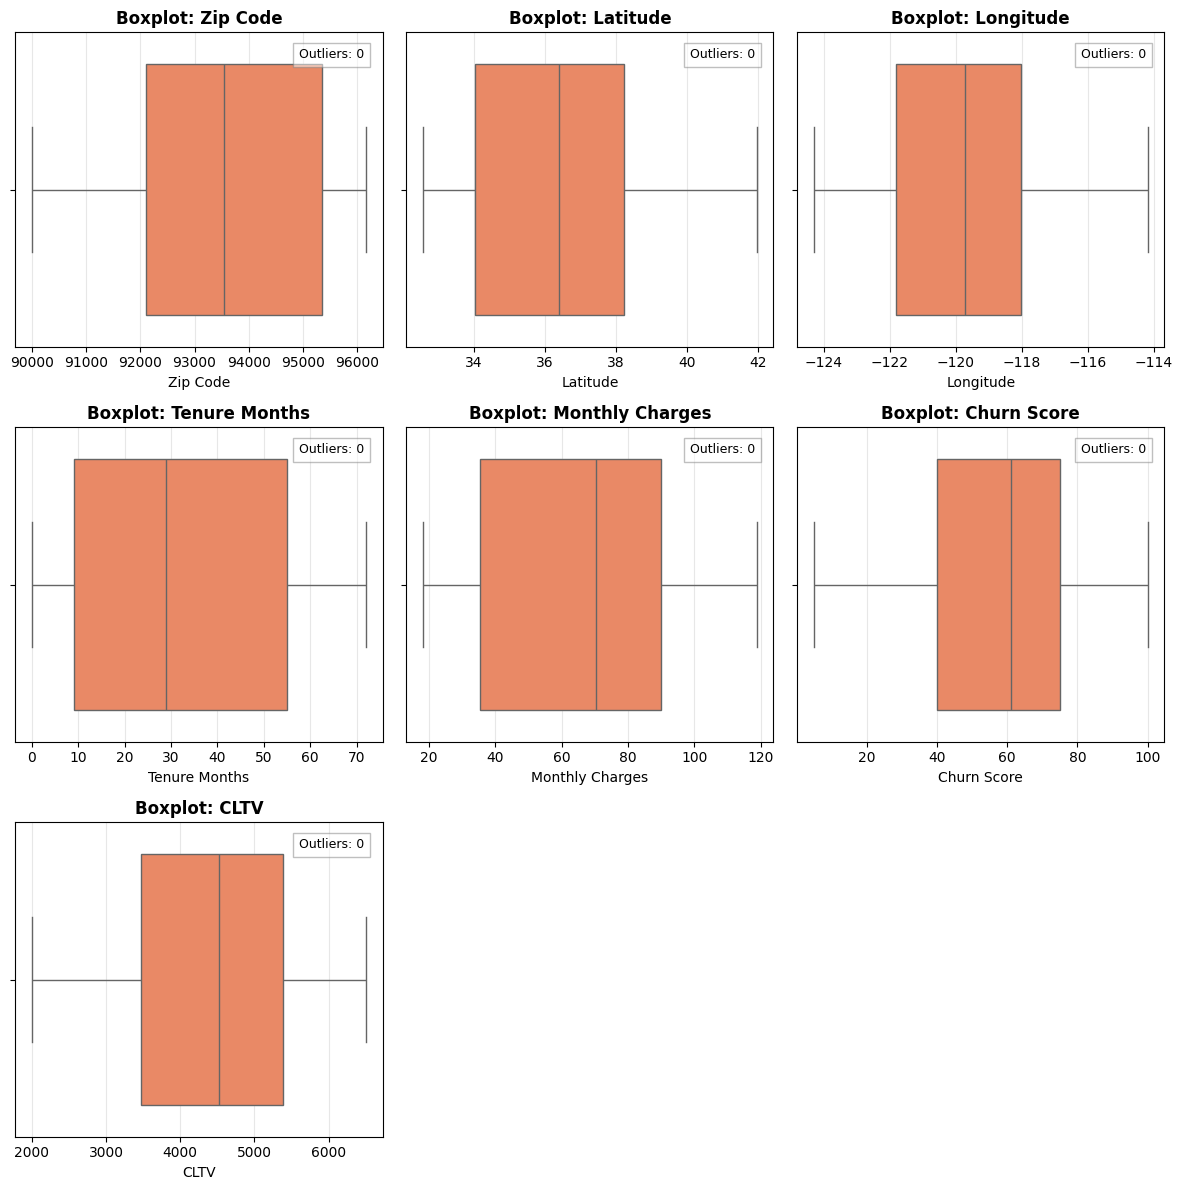

In [23]:
# Colunas numéricas (excluindo a variável target e id)

numeric_cols = df.select_dtypes(include=[np.number]).columns

# O errors='ignore' evita o KeyError caso o ID já tenha ficado de fora por ser string
to_drop = ['CustomerID', 'target', 'Count']
numeric_cols = numeric_cols.drop(to_drop, errors='ignore')

n = len(numeric_cols)
ncols= 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize =(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax= axes[idx], color='coral')
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(0.95, 0.95, f'Outliers: {outlier_count}',
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show() 


### 3.4 Análise de Anomalias e Valores Inválidos

**Objetivo:** Identificar valores que não fazem sentido no contexto de cancelamento